In [1]:
# ══════════════════════════════════════════════════════════════════
# CELL 1 — IMPORTS
# ══════════════════════════════════════════════════════════════════
# numpy for matrix operations (CKA is pure linear algebra)
# matplotlib and seaborn for heatmaps
# tqdm for progress bars since CKA over 12x12 layers takes a moment
# ══════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm

In [2]:
# ══════════════════════════════════════════════════════════════════
# CELL 2 — CONFIG
# ══════════════════════════════════════════════════════════════════
# All paths and constants in one place.
# Hidden states directory uses the 4k full files throughout.
# ══════════════════════════════════════════════════════════════════

BASE_PATH   = "/Users/harshaggarwal/Projects_4/hinemo_project/models"
HIDDEN_DIR  = f"{BASE_PATH}/hidden_states_full_means_4k_othwerwise_3k"
SAVE_DIR    = f"{BASE_PATH}/figures/phase9_cka_figures"
os.makedirs(SAVE_DIR, exist_ok=True)

models = [
    "bert-base-multilingual-cased",
    "muril-base-cased",
    "xlm-roberta-base"
]
states = ["pretrained", "finetuned"]

model_short = {
    "bert-base-multilingual-cased": "mBERT",
    "muril-base-cased"            : "MuRIL",
    "xlm-roberta-base"            : "XLM-R"
}

N_LAYERS = 12

print("Config loaded.")
print(f"Hidden states: {HIDDEN_DIR}")
print(f"Saving figures to: {SAVE_DIR}")

Config loaded.
Hidden states: /Users/harshaggarwal/Projects_4/hinemo_project/models/hidden_states_full_means_4k_othwerwise_3k
Saving figures to: /Users/harshaggarwal/Projects_4/hinemo_project/models/figures/phase9_cka_figures


In [4]:
# ══════════════════════════════════════════════════════════════════
# CELL 3 — LINEAR CKA FUNCTION
# ══════════════════════════════════════════════════════════════════
# Computes Centered Kernel Alignment between two representation
# matrices X and Y (both shape: n_samples × hidden_dim).
# Returns a scalar between 0 (completely different geometry)
# and 1 (identical geometry).
#
# Steps:
# 1. Center each matrix (subtract column means)
# 2. Compute gram matrices (XXT, YYT) — n×n pairwise similarities
# 3. Compute Frobenius inner product of gram matrices (numerator)
# 4. Normalize by product of Frobenius norms (denominator)
# ══════════════════════════════════════════════════════════════════

def linear_CKA(X, Y):
    # Step 1: center
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)

    # Step 2: gram matrices
    XXT = X @ X.T   # shape: (n_samples, n_samples)
    YYT = Y @ Y.T   # shape: (n_samples, n_samples)

    # Step 3: Frobenius inner product
    # np.sum(A * B) computes element-wise product then sums — this is
    # equivalent to trace(A.T @ B) but much faster for large matrices
    numerator = np.sum(XXT * YYT)

    # Step 4: normalize
    denominator = np.linalg.norm(XXT, "fro") * np.linalg.norm(YYT, "fro")

    return numerator / denominator

print("CKA function defined.")
print("Test with realistic dimensions (n=4000, d=768):")

np.random.seed(42)
X_test = np.random.randn(4000, 768)
Y_test = np.random.randn(4000, 768)

print(f"  CKA(X, X) = {linear_CKA(X_test, X_test):.4f}  ← should be 1.0")
print(f"  CKA(X, Y) = {linear_CKA(X_test, Y_test):.4f}  ← should be near 0")


CKA function defined.
Test with realistic dimensions (n=4000, d=768):
  CKA(X, X) = 1.0000  ← should be 1.0
  CKA(X, Y) = 0.1614  ← should be near 0


In [5]:
# ══════════════════════════════════════════════════════════════════
# CELL 4 — LOAD ALL HIDDEN STATES
# ══════════════════════════════════════════════════════════════════
# Loads the 4k full hidden states for all 3 models × 2 states.
# Stored as a dictionary keyed by (model, state).
# Shape of each array: (4000, 12, 768)
# ══════════════════════════════════════════════════════════════════

hidden = {}

for model in models:
    for state in states:
        path = f"{HIDDEN_DIR}/{model}/hidden_{state}_full.npy"
        arr  = np.load(path)
        hidden[(model, state)] = arr
        print(f"Loaded {model_short[model]} {state}: {arr.shape}")

print(f"\nTotal combinations loaded: {len(hidden)}")

Loaded mBERT pretrained: (4000, 12, 768)
Loaded mBERT finetuned: (4000, 12, 768)
Loaded MuRIL pretrained: (4000, 12, 768)
Loaded MuRIL finetuned: (4000, 12, 768)
Loaded XLM-R pretrained: (4000, 12, 768)
Loaded XLM-R finetuned: (4000, 12, 768)

Total combinations loaded: 6


In [6]:
# ══════════════════════════════════════════════════════════════════
# CELL 5 — WITHIN-MODEL CKA MATRICES
# ══════════════════════════════════════════════════════════════════
# For each model × state combination, computes a 12×12 CKA matrix
# where entry [i,j] = CKA(layer_i representations, layer_j
# representations). The diagonal is always 1.0 (a layer compared
# to itself). Off-diagonal values show how similar any two layers
# are geometrically.
#
# A block structure in this matrix (e.g. layers 1-4 all similar,
# layers 8-12 all similar, but the two blocks different from each
# other) indicates a phase transition — the model reorganizes its
# representations at that boundary. This transition point should
# align with the LSL found in Phase 7a.
# ══════════════════════════════════════════════════════════════════

within_cka = {}

for model in models:
    for state in states:
        key = (model, state)
        h   = hidden[key]   # shape: (4000, 12, 768)

        cka_matrix = np.zeros((N_LAYERS, N_LAYERS))

        print(f"\nComputing within-model CKA: {model_short[model]} {state}")
        for i in tqdm(range(N_LAYERS)):
            for j in range(N_LAYERS):
                cka_matrix[i, j] = linear_CKA(h[:, i, :], h[:, j, :])

        within_cka[key] = cka_matrix
        print(f"Done. Diagonal check (should be all 1.0): {np.diag(cka_matrix)}")


Computing within-model CKA: mBERT pretrained


100%|██████████| 12/12 [01:31<00:00,  7.62s/it]


Done. Diagonal check (should be all 1.0): [1.00006831 1.00007129 1.00006592 1.00007963 1.00007117 1.00006962
 1.00007463 1.00007045 1.00006902 1.00006282 1.00007248 1.00007737]

Computing within-model CKA: mBERT finetuned


100%|██████████| 12/12 [01:32<00:00,  7.70s/it]


Done. Diagonal check (should be all 1.0): [1.00005043 1.00005651 1.00007081 1.00008214 1.00007069 1.00005889
 1.00006104 1.000067   1.00006175 1.00004697 1.00004697 1.00005996]

Computing within-model CKA: MuRIL pretrained


...

Done. Diagonal check (should be all 1.0): [1.00007951 1.00006759 1.00003064 1.00003219 1.00005329 1.00005281
 1.00005317 1.00010693 1.00008607 1.00022852 1.00005817 1.00004601]

Computing within-model CKA: XLM-R pretrained


100%|██████████| 12/12 [00:39<00:00,  3.30s/it]


Done. Diagonal check (should be all 1.0): [1.00014412 1.00008118 1.00008225 1.00009179 1.00007308 1.00006998
 1.00007844 1.00034916 1.00008941 1.0001353  1.0001086  1.00015306]

Computing within-model CKA: XLM-R finetuned


100%|██████████| 12/12 [00:22<00:00,  1.86s/it]

Done. Diagonal check (should be all 1.0): [1.00007081 1.00006855 1.00008094 1.0000931  1.00008667 1.00007951
 1.00013661 1.00035489 1.00016701 1.00012517 1.00006413 1.00003755]


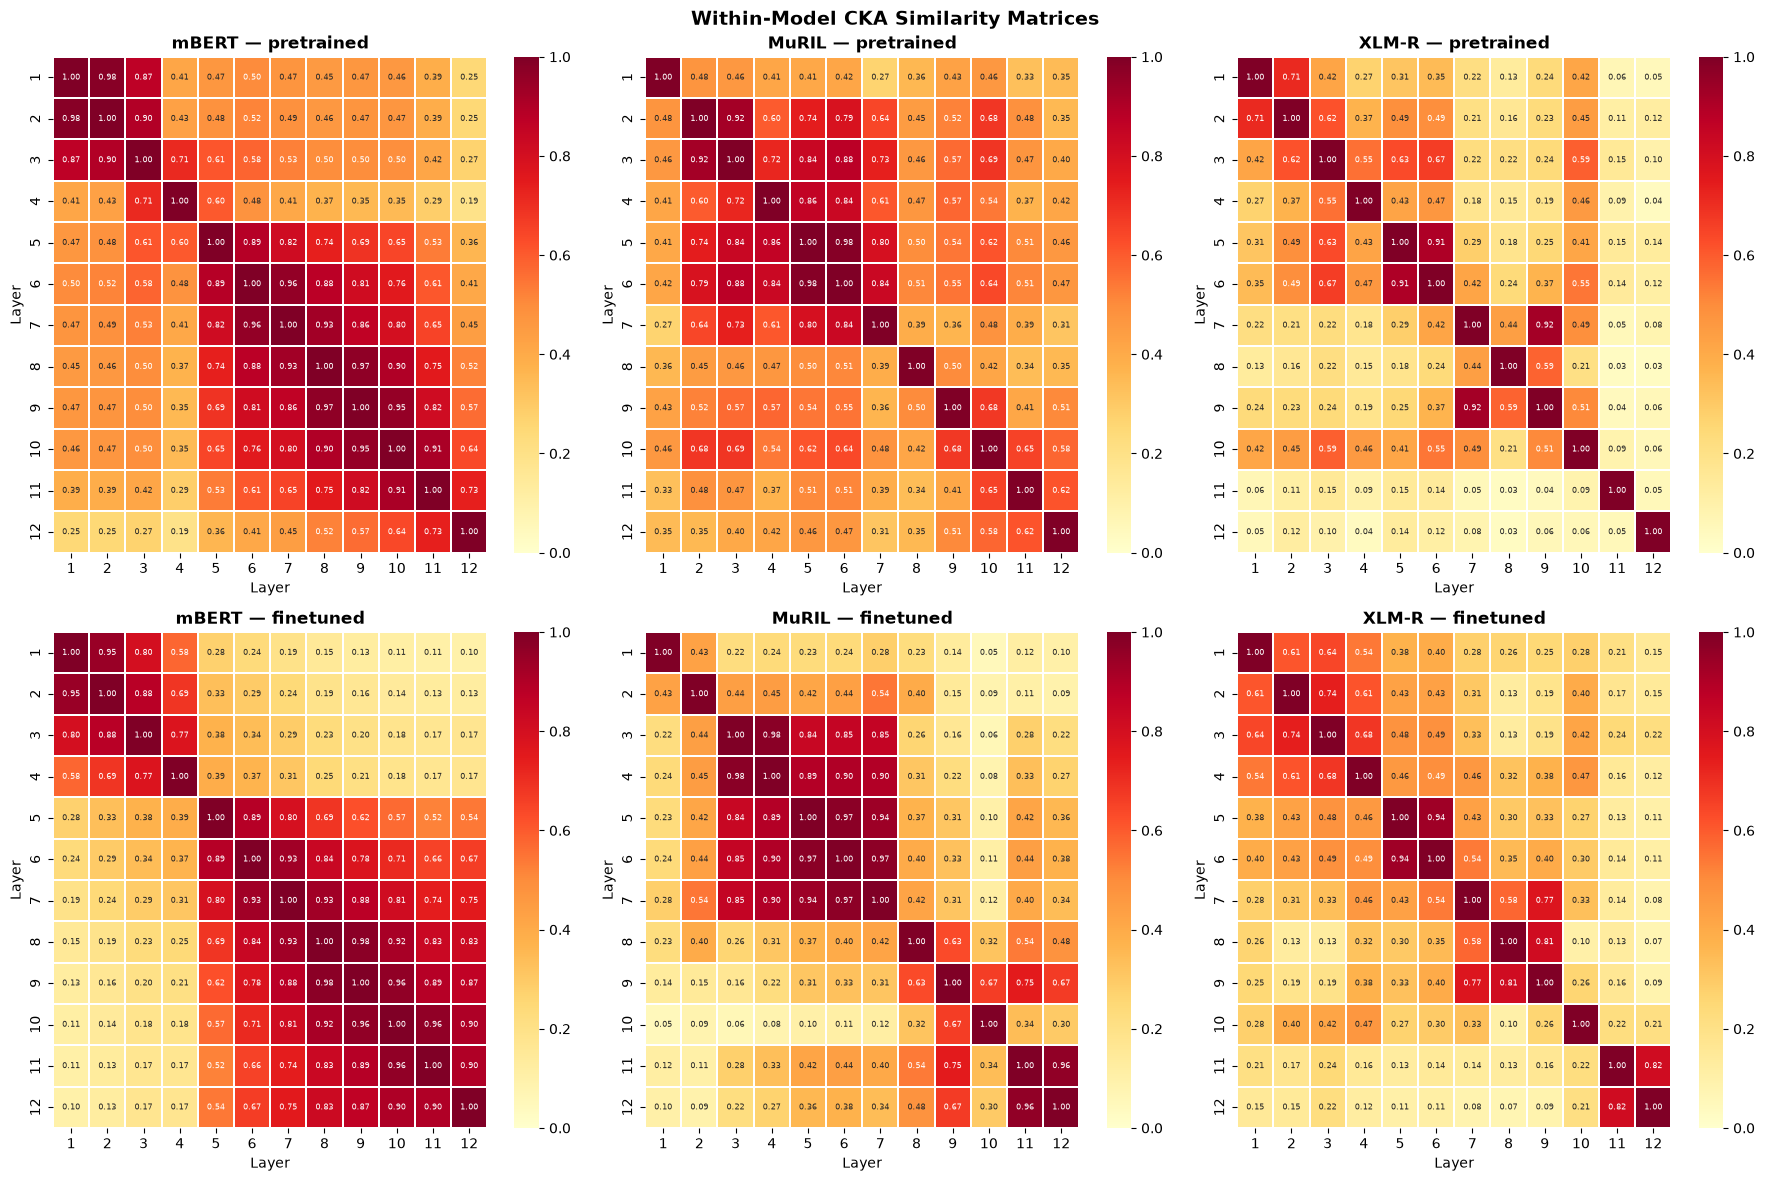

Saved.


In [7]:
# ══════════════════════════════════════════════════════════════════
# CELL 6 — PLOT WITHIN-MODEL CKA HEATMAPS
# ══════════════════════════════════════════════════════════════════
# 6 heatmaps (3 models × 2 states), each 12×12.
# Color = CKA similarity (yellow=high/similar, dark=low/different).
# Look for block structure — a clear boundary between early and
# late layers indicates a representational phase transition.
# The location of that boundary should match the LSL from Phase 7a.
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

layer_labels = [str(i) for i in range(1, 13)]

for col, model in enumerate(models):
    for row, state in enumerate(states):
        ax  = axes[row, col]
        mat = within_cka[(model, state)]

        sns.heatmap(
            mat,
            ax=ax,
            vmin=0, vmax=1,
            cmap="YlOrRd",
            xticklabels=layer_labels,
            yticklabels=layer_labels,
            annot=True,
            fmt=".2f",
            annot_kws={"size": 6},
            linewidths=0.3,
            linecolor="white",
            cbar=True
        )

        ax.set_title(f"{model_short[model]} — {state}",
                     fontsize=12, fontweight="bold")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Layer")

plt.suptitle("Within-Model CKA Similarity Matrices",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/within_model_cka.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

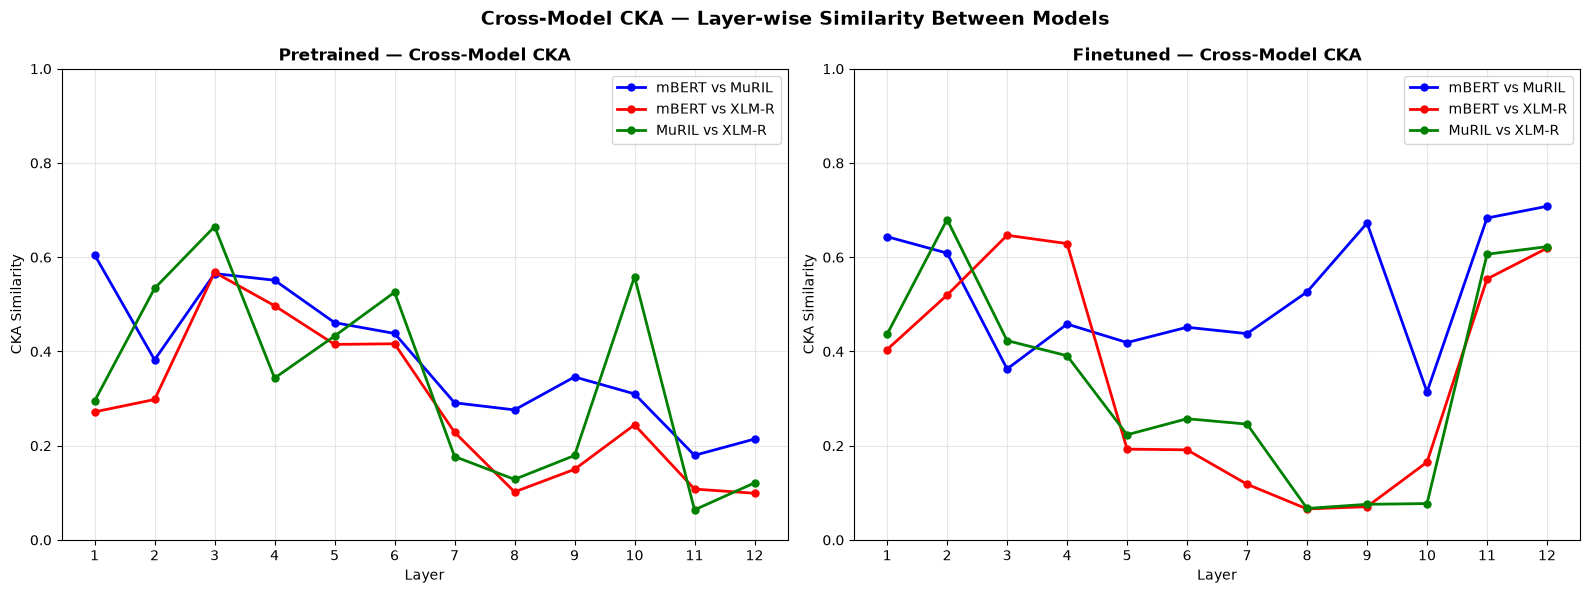

Saved.


In [8]:
# ══════════════════════════════════════════════════════════════════
# CELL 7 — CROSS-MODEL CKA
# ══════════════════════════════════════════════════════════════════
# For each pair of models, computes CKA between their corresponding
# layers (layer 1 of model A vs layer 1 of model B, etc.).
# High cross-model CKA at a given layer means both models organize
# that layer's representations similarly — despite being trained
# differently and having different architectures.
# Run for finetuned models only first, then pretrained.
# ══════════════════════════════════════════════════════════════════

from itertools import combinations

model_pairs = list(combinations(models, 2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for col, state in enumerate(states):
    ax = axes[col]

    pair_colors = ["blue", "red", "green"]

    for pair_idx, (model_a, model_b) in enumerate(model_pairs):
        h_a = hidden[(model_a, state)]
        h_b = hidden[(model_b, state)]

        cka_per_layer = []
        for layer in range(N_LAYERS):
            cka_val = linear_CKA(h_a[:, layer, :], h_b[:, layer, :])
            cka_per_layer.append(cka_val)

        label = f"{model_short[model_a]} vs {model_short[model_b]}"
        ax.plot(range(1, 13), cka_per_layer,
                label=label,
                color=pair_colors[pair_idx],
                linewidth=2,
                marker="o",
                markersize=5)

    ax.set_title(f"{state.capitalize()} — Cross-Model CKA",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Layer")
    ax.set_ylabel("CKA Similarity")
    ax.set_xticks(range(1, 13))
    ax.set_ylim(0, 1)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("Cross-Model CKA — Layer-wise Similarity Between Models",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cross_model_cka.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")